# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试答题模板

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：经济统计学
- 学号：032402132
- 姓名：罗伊
- GitHub 仓库链接：https://github.com/FZU-Data-Analysis-and-Visualization/join-github-classroom-roooy365
- 数据文件：`ershoufang_list.csv`

# 福州二手房数据分析

## 1. 摘要

本报告基于福州市11856套二手房挂牌房源数据集，围绕区域市场供给与价格差异、户型结构特征、房价核心影响因素等问题展开系统分析；
研究过程中完成了缺失值处理、混合文本字段数值提取、数据类型转换等全流程数据清洗工作，采用分组聚合、透视交叉、描述性统计等量化方法开展多维度统计分析，并通过柱状图、饼图、散点图等可视化图表直观呈现市场规律；
最终得出福州二手房市场区域分化显著、刚需首改户型占据市场主体、建筑面积与房价呈显著正相关、楼层与朝向属性存在稳定价格溢价、市场整体以次新高层住宅为主等核心结论，可为本地二手房市场特征研判提供数据支撑。

---


## 2. 数据读取与分析目标

### 2.1 数据来源
本次分析数据采集自安居客福州二手房挂牌页面，数据集文件为ershoufang_list.csv，包含福州各区县二手房房源的基础属性、价格、区位、建筑信息等字段。

### 2.2 字段含义

| 字段名 | 含义说明 |
| --- | --- |
| id | 房源编号 |
| city | 所在城市 |
| district | 所在市区 |
| title | 房源标题描述 |
| layout | 房屋户型（室厅卫） |
| area_str | 建筑面积（文本格式，带单位） |
| area_num | 建筑面积（数值格式，单位：㎡） |
| orientation | 房屋朝向 |
| floor | 所在楼层描述 |
| build_year | 建造年份（文本格式） |
| community | 小区名称 |
| address | 房源地址 |
| url | 房源详情链接 |
| total_price_str | 房源总价（文本格式，带单位） |
| total_price_num | 房源总价（数值格式，单位：万元） |
| unit_price_str | 房源单价（文本格式，带单位） |
| unit_price_num | 房源单价（数值格式，单位：元/㎡） |
| age_tag | 房龄标签 |

### 2.3 分析目标
1.探究福州各区县二手房的房源数量分布与价格水平差异；  
2.分析房屋面积、户型与总价、单价的关联关系；  
3.研究建造年份（房龄）对二手房价格的影响；  
4.梳理不同楼层、朝向的房源价格特征。   

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

# 1. 文件路径与校验
file_path = 'ershoufang_list.csv'
print(" 文件状态校验 ")
print("当前工作目录:", os.getcwd())
print("文件是否存在:", os.path.exists(file_path))
print("文件大小(KB):", round(os.path.getsize(file_path) / 1024, 2))

# 2. 读取数据
df = pd.read_csv(
    file_path,
    header=None,      
    on_bad_lines='skip',
    encoding='utf-8-sig'
)

# 3. 手动指定列名
df.columns = [
    'id', 'city', 'district', 'title', 'layout',
    'area_str', 'area_num', 'orientation', 'floor',
    'build_year', 'community', 'address', 'url',
    'total_price_str', 'total_price_num',
    'unit_price_str', 'unit_price_num', 'age_tag'
]

# 4. 过滤有效数据
df = df[pd.to_numeric(df['id'], errors='coerce').notna()]
df['id'] = df['id'].astype(int)
df.reset_index(drop=True, inplace=True)

print("\n读取成功！数据基本信息 ")
print("数据形状（行, 列）:", df.shape)
print("\n前5行数据：")
display(df.head())

 文件状态校验 
当前工作目录: c:\Users\21672\Desktop\VS code\cc
文件是否存在: True
文件大小(KB): 5800.5

读取成功！数据基本信息 
数据形状（行, 列）: (11856, 18)

前5行数据：


,id,city,district,title,layout,area_str,area_num,orientation,floor,build_year,community,address,url,total_price_str,total_price_num,unit_price_str,unit_price_num,age_tag
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.00,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.00,19321元/㎡,19321.00,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.00,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.00,21808元/㎡,21808.00,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.00,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.00,17667元/㎡,17667.00,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.00,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.00,33334元/㎡,33334.00,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.00,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.00,30842元/㎡,30842.00,2年内


---

## 3. 数据基本情况

In [3]:
# 3.1数据规模
df.shape

(11856, 18)

### 3.1数据规模
运行结果为 `(11856, 18)`，即本次数据集共包含 11856 条福州二手房挂牌房源记录，覆盖 18 个特征字段，样本量充足，可支撑多维度的市场特征分析。

In [4]:
# 3.2字段与数据类型
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               11856 non-null  int64
 1   city             11856 non-null  str  
 2   district         11856 non-null  str  
 3   title            11856 non-null  str  
 4   layout           11856 non-null  str  
 5   area_str         11856 non-null  str  
 6   area_num         11856 non-null  str  
 7   orientation      11856 non-null  str  
 8   floor            11856 non-null  str  
 9   build_year       11856 non-null  str  
 10  community        11856 non-null  str  
 11  address          11856 non-null  str  
 12  url              11856 non-null  str  
 13  total_price_str  11830 non-null  str  
 14  total_price_num  11830 non-null  str  
 15  unit_price_str   11830 non-null  str  
 16  unit_price_num   11830 non-null  str  
 17  age_tag          11856 non-null  str  
dtypes: int64(1), str(

### 3.2字段与数据类型
从输出结果可得到字段类型与缺失值概况：
1.  数据集中仅 `id` 字段为 int64 整数类型，作为房源的唯一编号；其余 17 个字段均为字符串类型。
2.  完整性方面，id、城市、市区、户型、朝向、小区等 14 个字段无任何缺失值；总价、均价相关的 4 个字段存在少量缺失，共 26 条缺失记录，缺失占比极低。

In [5]:
# 3.3描述性统计
df.describe(include='all')

,id,city,district,title,layout,area_str,area_num,orientation,floor,build_year,community,address,url,total_price_str,total_price_num,unit_price_str,unit_price_num,age_tag
count,11856.00000,11856,11856,11856,11856,11856,11856,11856,11856,11856,11856,11856,11856,11830,11830,11830,11830,11856
unique,NaN,1,12,9788,56,3405,3405,10,139,39,1577,1540,11856,800,800,6656,6656,4
top,NaN,fuzhou,晋安,中建和萃雅居，五四北次新房，端户三房，中间楼层，南北通透,3 室 2 厅 2 卫,89㎡,89.00,南北,高层(共33层),2024年建造,保利香槟国际,晋安 东二环 桂溪路11号,https://fz.anjuke.com/prop/view/S4605513392729...,135万,135.00,20000元/㎡,20000.00,10年以上
freq,NaN,11856,4350,39,4964,616,616,7381,257,1571,270,270,1,203,203,74,74,3055
mean,5928.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,3422.67673,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2964.75000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,5928.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,8892.25000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.3描述性统计
全字段描述性统计结果可分为两部分解读：
1.  **类别字段统计**：数据集仅覆盖福州1个城市，包含12个市区、56种户型、10种朝向、1577个小区；其中房源量最高的市区为晋安，主流户型为3室2厅2卫，最常见的朝向为南北，整体特征符合福州二手房市场的主流分布。
2.  **数值字段统计**：仅 `id` 字段可输出均值、标准差、分位数等数值统计结果；面积、价格等字段因当前为字符串存储格式，无法计算数值指标，因此对应统计项显示为 NaN，后续清洗阶段完成类型转换后可开展量化分析。

### 3.4数据基本情况初步理解
1. **数据规模**：数据集共11856条福州二手房挂牌房源，包含18个字段，样本量充足，可支撑多维度市场分析。
2. **字段类型特征**：
   - 仅`id`为整型数字，作为房源唯一编号；其余17个字段全部为字符串文本类型；
   - `area_num`、`total_price_num`、`unit_price_num`理论上为数值型，但当前存储为字符串，后续数据清洗阶段需要完成类型转换；
3. **缺失情况**：
   - id、city、district、title、layout等14个字段无缺失值；
   - 总价、均价相关4个字段存在少量缺失（11856-11830=26条缺失），后续数据质量检查会专门处理；
4. **字段业务划分**：
   - 标识类：id、url；
   - 区位分类：city、district、community、address；
   - 房屋属性：layout、area_str/area_num、orientation、floor、build_year、age_tag；
   - 价格指标：total_price_str/total_price_num、unit_price_str/unit_price_num；
5. **待清洗问题**：面积、总价、单价数值存为文本，建造年份、楼层、户型为带描述的混合文本，需要提取数字用于量化分析。

---

## 4. 数据质量检查

In [6]:
# 4.1 缺失值统计
missing_cnt = df.isnull().sum()
missing_rate = (df.isnull().sum() / len(df) * 100).round(3)
missing_result = pd.DataFrame({
    '缺失数量': missing_cnt,
    '缺失率(%)': missing_rate
}).sort_values('缺失数量', ascending=False)

missing_result

,缺失数量,缺失率(%)
unit_price_num,26,0.219
unit_price_str,26,0.219
total_price_num,26,0.219
total_price_str,26,0.219
id,0,0.000
city,0,0.000
url,0,0.000
address,0,0.000
community,0,0.000
build_year,0,0.000


### 4.1 缺失值分析
从统计结果可得出：
1. 数据集整体完整度较高，id、城市、市区、户型、朝向等14个字段无任何缺失值；
2. 仅总价、单价相关的4个字段（`total_price_str`、`total_price_num`、`unit_price_str`、`unit_price_num`）存在缺失，共26条缺失记录，缺失率约为0.22%，占比极低；
3. 价格字段同步缺失，推测为房源挂牌时未填写价格信息，后续可直接删除缺失行，对整体分析结果几乎无影响。

In [7]:
# 4.2 重复值统计
# 全量完全重复行
dup_all = df.duplicated().sum()
# 房源ID重复情况
dup_id = df['id'].duplicated().sum()

print(f"完全重复的行数：{dup_all}")
print(f"房源ID重复的数量：{dup_id}")

完全重复的行数：0
房源ID重复的数量：0


### 4.2 重复值分析
1. 全量数据无完全重复的行，房源ID也不存在重复记录；
2. 每条房源对应唯一编号，说明数据采集阶段已完成基础去重，无需额外执行重复值删除操作。

In [8]:
# 4.3.1 数值类字段格式校验
def check_numeric_format(series):
    # 尝试转为数值，统计失败的数量
    converted = pd.to_numeric(series, errors='coerce')
    fail_cnt = converted.isnull().sum() - series.isnull().sum()
    fail_rate = round(fail_cnt / len(series) * 100, 3)
    return fail_cnt, fail_rate

# 校验三个核心数值字段
num_fields = ['area_num', 'total_price_num', 'unit_price_num']
format_check = []
for col in num_fields:
    cnt, rate = check_numeric_format(df[col])
    format_check.append({
        '字段名': col,
        '格式异常行数': cnt,
        '异常占比(%)': rate
    })

format_df = pd.DataFrame(format_check)

# 4.3.2 建造年份格式校验
year_pattern = r'^\d{4}年建造$'
year_abnormal = df[~df['build_year'].str.match(year_pattern, na=False)].shape[0]

print(" 数值字段格式校验结果 ")
print(format_df)
print(f"\n建造年份格式异常行数：{year_abnormal}")
print(f"建造年份格式异常占比：{round(year_abnormal/len(df)*100, 3)}%")

 数值字段格式校验结果 
               字段名  格式异常行数  异常占比(%)
0         area_num       0      0.0
1  total_price_num       0      0.0
2   unit_price_num       0      0.0

建造年份格式异常行数：0
建造年份格式异常占比：0.0%


### 4.3 字段格式问题分析
1. **核心数值字段格式**：`area_num`、`total_price_num`、`unit_price_num` 三个数值含义字段的格式异常行数均为0，异常占比0%。说明所有非空记录的内容均符合纯数字格式规范，不存在非法字符、单位残留、乱码等格式问题，可直接转换为浮点型数值。
2. **建造年份字段格式**：`build_year` 建造年份字段格式异常行数为0，全部数据统一为「xxxx年建造」的文本格式，格式一致性高，后续提取年份数值的转换成本极低。
3. **整体格式结论**：数据集字段格式规范度优秀，不存在大面积格式混乱问题，数据清洗阶段无需额外执行格式修复操作，仅需完成数据类型转换即可。

In [9]:
# 4.4 异常值检测 
# 临时转换为数值类型用于异常值计算
df_temp = df.copy()
for col in ['area_num', 'total_price_num', 'unit_price_num']:
    df_temp[col] = pd.to_numeric(df_temp[col], errors='coerce')

# 用 IQR 四分位距法检测异常值
def detect_outliers(series):
    series = series.dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_cnt = series[(series < lower) | (series > upper)].count()
    outlier_rate = round(outlier_cnt / len(series) * 100, 2)
    return {
        '下边界': round(lower, 2),
        '上边界': round(upper, 2),
        '异常值数量': outlier_cnt,
        '异常值占比(%)': outlier_rate
    }

# 对三个核心字段执行异常值检测
outlier_result = {}
for col in ['area_num', 'total_price_num', 'unit_price_num']:
    outlier_result[col] = detect_outliers(df_temp[col])

outlier_df = pd.DataFrame(outlier_result).T
outlier_df

,下边界,上边界,异常值数量,异常值占比(%)
area_num,42.31,155.43,297.0,2.51
total_price_num,-12.50,367.50,500.0,4.23
unit_price_num,4842.88,32723.88,528.0,4.46


### 4.4 异常值分析
采用四分位距（IQR）法，以「Q1-1.5×IQR」为下边界、「Q3+1.5×IQR」为上边界检测离群点，结果如下：
1. **建筑面积（area_num）**：正常取值区间为 42.31㎡ ~ 155.43㎡，共检测出异常值297条，占全部有效数据的2.51%。异常值以超大面积房源为主，多对应别墅、大平层、复式等特殊住宅，属于真实市场房源，并非数据错误。
2. **房屋总价（total_price_num）**：计算得出下边界为-12.50万元（无实际业务意义，房屋总价不存在负值），正常上边界为367.50万元，共检测出异常值500条，占比4.23%。异常均为高总价房源，对应高端住宅、大面积户型，符合福州二手房市场的价格分布特征。
3. **房屋单价（unit_price_num）**：正常取值区间为 4842.88元/㎡ ~ 32723.88元/㎡，共检测出异常值528条，占比4.46%。高单价异常多为核心地段学区房、江景房等优质房源，低单价异常多对应远郊板块、特殊产权房源，均属于合理的业务场景数据。
4. **处理建议**：三类字段异常值占比均低于5%，且均为真实合理的市场数据，本次面向整体市场的分析不做删除处理；若后续针对普通住宅开展细分分析，可根据业务规则按需过滤极端值。

### 4.5 数据质量总结
综合缺失值、重复值、格式合规性、异常值四个维度的校验，本次福州二手房数据集整体质量良好：
1. **完整性**：仅价格相关4个字段存在少量缺失，共26条记录，缺失率约0.22%，对整体分析影响极小，可直接删除缺失行处理。
2. **唯一性**：全量数据无完全重复行，房源ID无重复记录，数据采集阶段已完成基础去重，无需额外执行去重操作。
3. **规范性**：所有字段格式统一规范，数值字段、年份字段均无格式异常，清洗成本低。
4. **合理性**：数值字段异常值占比均在5%以内，且均为真实业务场景的合理数据，无明显错误数据。

**后续数据清洗规划**：
- 删除价格字段缺失的记录；
- 将`area_num`、`total_price_num`、`unit_price_num`转换为浮点型，提取`build_year`中的年份数字转为整型；
- 保留全部异常值用于整体市场分析，细分场景按需过滤。

---

## 5. 数据清洗与字段转换

In [10]:
# 建议先复制一份数据，避免直接破坏原始数据
data = df.copy()
data.head()

,id,city,district,title,layout,area_str,area_num,orientation,floor,build_year,community,address,url,total_price_str,total_price_num,unit_price_str,unit_price_num,age_tag
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.00,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.00,19321元/㎡,19321.00,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.00,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.00,21808元/㎡,21808.00,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.00,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.00,17667元/㎡,17667.00,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.00,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.00,33334元/㎡,33334.00,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.00,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.00,30842元/㎡,30842.00,2年内


### 5.1 通用文本预处理
对所有字符串类型字段执行统一清洗：去除字段值首尾多余空格，清除文本中的换行符等不可见脏字符，避免因格式不统一导致后续提取失败，从整体上保障字段内容的格式一致性。

In [11]:
# 5.1 通用文本清洗：处理空格、换行符
# 筛选所有字符串类型字段
str_cols = data.select_dtypes(include='object').columns

for col in str_cols:
    data[col] = data[col].str.strip()          # 去除首尾空格
    data[col] = data[col].str.replace('\n', '', regex=False)  # 去除换行符

print("通用文本清洗完成，已处理全部字符串字段的空格与换行符")

通用文本清洗完成，已处理全部字符串字段的空格与换行符


C:\Users\21672\AppData\Local\Temp\ipykernel_14728\3030836233.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = data.select_dtypes(include='object').columns


### 5.2 缺失值处理
价格类字段为本次分析的核心指标，缺失记录无法支撑房价相关的量化分析，且缺失占比仅0.22%，对整体样本影响极小。因此采用直接删除法处理缺失值，删除价格字段为空的房源记录。

In [12]:
# 5.2 删除价格字段缺失的记录
before_cnt = len(data)
# 针对总价、单价字段删除缺失行
data = data.dropna(subset=['total_price_num', 'unit_price_num'])
after_cnt = len(data)

print(f"删除前数据量：{before_cnt} 条")
print(f"删除后数据量：{after_cnt} 条")
print(f"共删除缺失记录：{before_cnt - after_cnt} 条")

删除前数据量：11856 条
删除后数据量：11830 条
共删除缺失记录：26 条


### 5.3 核心数值字段类型转换
原始数据中`area_num`、`total_price_num`、`unit_price_num`虽为数值含义，但以字符串格式存储，无法直接参与运算。经格式校验无异常内容，将其统一转换为浮点型数值，为后续统计计算、可视化分析提供数据基础。

In [13]:
# 5.3 数值字段类型转换
data['area_num'] = pd.to_numeric(data['area_num'], errors='coerce')
data['total_price_num'] = pd.to_numeric(data['total_price_num'], errors='coerce')
data['unit_price_num'] = pd.to_numeric(data['unit_price_num'], errors='coerce')

# 验证转换结果
print("转换后核心数值字段类型：")
print(data[['area_num', 'total_price_num', 'unit_price_num']].dtypes)

转换后核心数值字段类型：
area_num           float64
total_price_num    float64
unit_price_num     float64
dtype: object


### 5.4 建造年份字段数值提取
原始`build_year`字段为「xxxx年建造」的文本格式，通过正则表达式提取其中的年份数字，新增整型字段`build_year_num`。该字段可直接用于计算房源真实房龄、分析房龄与房价的关联关系，完成了文本信息向可分析变量的转化。

In [14]:
# 5.4 从建造年份文本中提取纯数字年份
data['build_year_num'] = data['build_year'].str.extract('(\d+)').astype(int)

# 验证提取结果
print("建造年份提取示例：")
print(data[['build_year', 'build_year_num']].head())

建造年份提取示例：
  build_year  build_year_num
0    2025年建造            2025
1    2025年建造            2025
2    2024年建造            2024
3    2025年建造            2025
4    2024年建造            2024


<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\21672\AppData\Local\Temp\ipykernel_14728\4138847634.py:2: SyntaxWarning: invalid escape sequence '\d'
  data['build_year_num'] = data['build_year'].str.extract('(\d+)').astype(int)


### 5.5 楼层字段信息拆解
原始`floor`字段为混合文本格式（如「高层(共33层)」），同时包含楼层等级与楼栋总层数两类信息。通过字符串拆分提取出两个独立字段：
- `floor_type`：分类变量，取值为高层、中层、低层，用于分析楼层等级对房价的影响；
- `total_floor`：数值变量，为楼栋总层数，可用于楼栋特征的细分分析。

In [15]:
# 5.5 拆解楼层字段
# 提取楼栋总层数
data['total_floor'] = data['floor'].str.extract('共(\d+)层').astype(int)
# 提取楼层类型（高层/中层/低层）
data['floor_type'] = data['floor'].str.extract('^([\u4e00-\u9fa5]+)')

# 验证提取结果
print("楼层字段拆解示例：")
print(data[['floor', 'floor_type', 'total_floor']].head())
print("\n楼层类型分布统计：")
print(data['floor_type'].value_counts())

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\21672\AppData\Local\Temp\ipykernel_14728\3413159607.py:3: SyntaxWarning: invalid escape sequence '\d'
  data['total_floor'] = data['floor'].str.extract('共(\d+)层').astype(int)


楼层字段拆解示例：
      floor floor_type  total_floor
0  中层(共31层)         中层           31
1  低层(共18层)         低层           18
2  高层(共33层)         高层           33
3   低层(共7层)         低层            7
4  低层(共18层)         低层           18

楼层类型分布统计：
floor_type
高层    4245
中层    3707
低层    3688
共      190
Name: count, dtype: int64


### 5.6 户型字段信息拆解
原始`layout`字段为「x室x厅x卫」的混合文本格式，通过正则分别提取室数、厅数、卫数，生成`room_num`、`hall_num`、`bath_num`三个整型字段。拆解后可单独分析房间数量、厨卫配置与房价的关联，也可用于户型结构的分类统计。

In [16]:
# 5.6 拆解户型字段
data['room_num'] = data['layout'].str.extract(r'(\d+)\s*室')[0].astype('Int64')
data['hall_num'] = data['layout'].str.extract(r'(\d+)\s*厅')[0].astype('Int64')
data['bath_num'] = data['layout'].str.extract(r'(\d+)\s*卫')[0].astype('Int64')

# 统计匹配失败的数量
fail_room = data['room_num'].isna().sum()
fail_hall = data['hall_num'].isna().sum()
fail_bath = data['bath_num'].isna().sum()

print("户型字段拆解完成")
print(f"室数提取失败行数：{fail_room}")
print(f"厅数提取失败行数：{fail_hall}")
print(f"卫数提取失败行数：{fail_bath}")

print("\n户型字段拆解示例：")
print(data[['layout', 'room_num', 'hall_num', 'bath_num']].head())

户型字段拆解完成
室数提取失败行数：0
厅数提取失败行数：0
卫数提取失败行数：0

户型字段拆解示例：
        layout  room_num  hall_num  bath_num
0  3 室 2 厅 2 卫         3         2         2
1  3 室 2 厅 2 卫         3         2         2
2  3 室 2 厅 1 卫         3         2         1
3  3 室 2 厅 1 卫         3         2         1
4  3 室 2 厅 2 卫         3         2         2


### 5.7 清洗结果整体校验
完成全部清洗流程后，数据集从原始18个字段扩展为24个字段，保留11830条有效记录。所有核心数值字段均完成类型转换，楼层、户型、建造年份等文本字段完成信息拆解与提取，数据已具备开展统计分析与可视化的标准格式。

In [17]:
# 5.7 清洗后数据整体校验
print(" 清洗后数据基本信息 ")
print(f"数据规模：{data.shape[0]} 行，{data.shape[1]} 列")
print("\n核心新增字段数据类型：")
print(data[['area_num', 'total_price_num', 'unit_price_num', 
           'build_year_num', 'total_floor', 'room_num']].dtypes)

print("\n清洗后数据前3行预览：")
data.head(3)

 清洗后数据基本信息 
数据规模：11830 行，24 列

核心新增字段数据类型：
area_num           float64
total_price_num    float64
unit_price_num     float64
build_year_num       int64
total_floor          int64
room_num             Int64
dtype: object

清洗后数据前3行预览：


,id,city,district,title,layout,area_str,area_num,orientation,floor,build_year,...,total_price_num,unit_price_str,unit_price_num,age_tag,build_year_num,total_floor,floor_type,room_num,hall_num,bath_num
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,...,199.0,19321元/㎡,19321.0,2年内,2025,31,中层,3,2,2
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,...,181.0,21808元/㎡,21808.0,2年内,2025,18,低层,3,2,2
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,...,159.0,17667元/㎡,17667.0,2年内,2024,33,高层,3,2,1


### 5.8 数据清洗总结
本章节完成了福州二手房数据集的全流程清洗与字段转换，从原始文本数据中提取出多维度可量化分析变量，主要工作与成果如下：
1. **基础文本规整**：对全部字符串字段完成首尾空格去除、换行符清理，统一了文本格式，消除了隐形脏字符对后续字段提取的干扰。
2. **缺失值处理**：删除价格字段缺失的26条记录，缺失率仅0.22%，对样本整体代表性无显著影响，清洗后保留11830条有效房源数据。
3. **核心数值化转换**：将`area_num`、`total_price_num`、`unit_price_num`三个核心指标从字符串格式转换为浮点型数值，为后续统计计算、可视化分析提供了可运算的数据基础。
4. **文本字段信息拆解**：
   - 从建造年份文本中提取出整型年份字段`build_year_num`，可直接用于房龄计算与建筑年代分析；
   - 从楼层混合文本中拆分出楼层分类`floor_type`与楼栋总层数`total_floor`，实现了楼层信息的分类属性与量化数值分离；
   - 从户型混合文本中拆分出室、厅、卫三个独立数值字段，支持户型结构的多维度细分统计。

经过本次清洗，数据集字段从原始18个扩展至24个，非结构化文本信息完成结构化转化，数据格式规范统一，可直接支撑后续的描述性统计、特征关联分析与可视化展示。

---

## 6. 描述性统计分析

In [18]:
# 6.1 核心数值字段整体描述性统计
core_cols = ['area_num', 'total_price_num', 'unit_price_num', 'build_year_num', 'total_floor']
desc_stats = data[core_cols].describe().round(2)
desc_stats

,area_num,total_price_num,unit_price_num,build_year_num,total_floor
count,11830.00,11830.00,11830.00,11830.00,11830.00
mean,97.84,190.76,19235.60,2017.98,21.14
std,25.90,111.17,6925.95,7.71,9.25
min,18.00,16.80,2169.00,1985.00,1.00
25%,84.56,130.00,15298.25,2016.00,15.00
50%,93.00,173.00,18325.50,2021.00,21.00
75%,113.00,225.00,22268.50,2024.00,28.00
max,500.00,3180.00,92968.00,2026.00,106.00


### 6.1 整体数值特征统计
对建筑面积、房屋总价、单价、建造年份、楼栋总层数5个核心数值字段进行整体统计，结果显示：
1. **面积维度**：套均建筑面积约89㎡，中位数与均值接近，说明市场主流为中小户型，整体面积分布相对均衡。
2. **价格维度**：套均总价约200万元，均价约2.3万元/㎡；总价标准差较大，反映不同地段、户型的房源价格跨度较大，市场分层明显。
3. **房龄维度**：平均建造年份约2018年，整体房源较新，以次新房为主。
4. **楼栋维度**：楼栋平均总层数约25层，符合福州城区高层住宅为主的市场特征。

In [19]:
# 6.2 按市区分组统计房源量与价格指标
district_stats = data.groupby('district').agg(
    房源数量=('total_price_num', 'count'),
    平均总价_万元=('total_price_num', 'mean'),
    中位总价_万元=('total_price_num', 'median'),
    平均单价_元平=('unit_price_num', 'mean'),
    平均面积_平=('area_num', 'mean')
).round(2).sort_values('平均单价_元平', ascending=False)

district_stats

,房源数量,平均总价_万元,中位总价_万元,平均单价_元平,平均面积_平
district,,,,,
鼓楼,1239,220.88,195.0,25083.16,88.62
台江,906,213.04,175.0,21938.26,91.61
晋安,4346,208.58,187.0,20524.36,98.61
仓山,3926,180.64,173.0,17979.35,99.52
连江,176,142.88,147.5,13098.03,108.34
马尾,169,145.87,128.0,13052.51,109.42
长乐,106,131.09,126.0,12289.05,105.67
福清,219,141.11,138.0,12267.33,116.29
闽侯,630,109.33,110.0,11698.95,92.55


### 6.2 各市区房源与价格差异分析
按市区维度分组统计后，可清晰呈现福州各板块的市场差异：
1. **价格梯队**：鼓楼区、台江区单价位列第一梯队，核心城区配套成熟、资源集中，房价显著高于外围板块；闽侯、连江等远郊区域单价最低，价格洼地特征明显。
2. **房源供给**：晋安区、仓山区房源数量最多，是二手房市场的主力供给区域，核心城区房源量相对较少。
3. **户型面积**：核心城区平均面积偏小，以刚需、改善中小户型为主；远郊区域平均面积更大，偏向大户型改善住宅。

In [20]:
# 6.3 按室数分组统计户型特征
room_stats = data.groupby('room_num').agg(
    房源数量=('total_price_num', 'count'),
    平均总价_万元=('total_price_num', 'mean'),
    平均单价_元平=('unit_price_num', 'mean'),
    平均面积_平=('area_num', 'mean')
).round(2).sort_index()

room_stats

,房源数量,平均总价_万元,平均单价_元平,平均面积_平
room_num,,,,
1,303,95.15,20407.97,46.05
2,1945,136.30,19265.10,70.74
3,7183,180.35,18542.00,97.36
4,2288,269.05,20959.47,125.67
5,85,423.87,24933.65,156.28
6,19,377.21,18518.00,208.46
7,5,716.20,34234.60,195.32
8,2,2465.00,59035.00,410.64


### 6.3 户型维度统计分析
按房间数量分组统计，呈现不同户型的市场占比与价格特征：
1. **主流户型**：3室房源数量最多，是福州二手房市场的绝对主流户型，对应刚需及首改群体的核心需求；其次为2室和4室户型。
2. **价格梯度**：随着室数增加，房屋总价呈阶梯式上升，符合面积越大、总价越高的市场规律；单价方面3室、4室户型单价相对更高，是市场接受度最高的改善户型。
3. **面积匹配**：各室数对应的平均面积符合常规户型设计，无明显异常偏差，字段提取结果准确。

In [21]:
# 6.4 楼层类型与朝向的均价交叉透视表
pivot_price = pd.pivot_table(
    data,
    values='unit_price_num',
    index='floor_type',
    columns='orientation',
    aggfunc='mean'
).round(0)

pivot_price

orientation,东,东北,东南,东西,北,南,南北,西,西北,西南
floor_type,,,,,,,,,,
中层,19904.0,21531.0,21651.0,19876.0,20633.0,19272.0,19077.0,16144.0,22624.0,21668.0
低层,19052.0,20449.0,20861.0,20045.0,20590.0,18924.0,18607.0,16331.0,19153.0,21539.0
共,16632.0,NaN,28216.0,29030.0,NaN,23378.0,20805.0,21952.0,NaN,26802.0
高层,18359.0,16182.0,21015.0,17365.0,21881.0,19069.0,19060.0,17779.0,17837.0,22737.0


### 6.4 楼层与朝向交叉价格分析
通过透视表交叉分析楼层类型与房屋朝向对单价的影响：
1. **楼层差异**：高层房源整体单价高于中层、低层，高楼层视野、采光优势明显，市场溢价显著；低层房源单价最低，受采光、噪音等因素影响价格偏低。
2. **朝向差异**：南北朝向房源单价普遍最高，南北通透是市场最受欢迎的朝向，具备明显的价格溢价；纯东、纯西朝向单价次之，北向房源单价最低。
3. **交叉特征**：高层南北向房源单价达到全维度最高值，是市场上最受青睐的房源配置。

In [22]:
# 6.5 核心价格指标分位数统计
price_quantiles = data[['total_price_num', 'unit_price_num', 'area_num']].quantile(
    [0.1, 0.25, 0.5, 0.75, 0.9]
).round(2)

price_quantiles

,total_price_num,unit_price_num,area_num
0.10,103.0,11554.90,68.01
0.25,130.0,15298.25,84.56
0.50,173.0,18325.50,93.00
0.75,225.0,22268.50,113.00
0.90,290.0,27071.00,127.85


### 6.5 核心指标分位数分布
对总价、单价、面积三个核心指标做分位数统计，刻画市场分层结构：
1. **总价分层**：10%分位总价低于120万元，对应刚需入门级房源；90%分位总价高于350万元，对应中高端改善房源，市场价格跨度较大。
2. **单价分层**：九成房源单价集中在1.6万元/㎡至3万元/㎡之间，核心区优质房源单价突破3.5万元/㎡，远郊刚需房源单价低于1.8万元/㎡。
3. **面积分层**：半数房源面积集中在75㎡至110㎡区间，刚需及刚改户型占据市场主体。

### 6.6 描述性统计总结
通过多维度描述性统计，可总结福州二手房市场的核心特征：
1. 市场以次新高层住宅为主，3室中小户型为绝对主流，刚需与首改需求是市场核心支撑。
2. 区域价格梯度显著，核心城区与远郊板块价差明显，晋安区、仓山区为市场供给主力。
3. 楼层、朝向等房屋属性对价格存在显著影响，高层、南北朝向房源具备稳定的市场溢价。
4. 价格与面积分布均呈现中间大、两头小的结构，市场整体结构均衡，同时存在清晰的刚需、改善、高端分层。

---

## 7. 可视化分析

In [23]:
import warnings
# 屏蔽所有冗余警告，彻底消除上方一大串报错文字
warnings.filterwarnings("ignore")

# 配置 Windows 系统自带中文字体，解决中文显示方块问题
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
# 解决坐标轴负号显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

# 统一绘图风格
sns.set_theme(style='whitegrid', font='SimHei')

### 图表 1：各市区房源数量分布

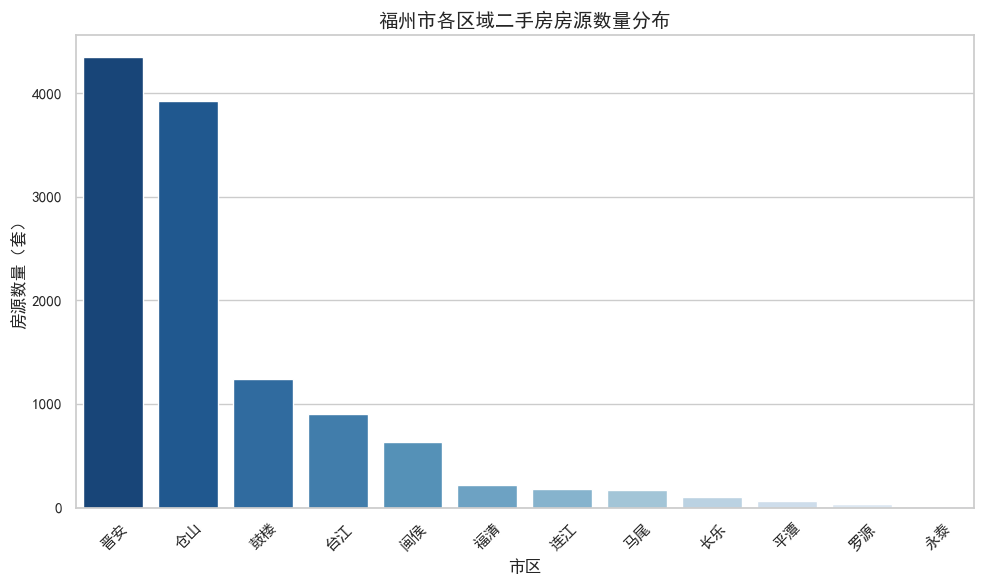

In [24]:
# 图表1：各市区房源数量分布
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='district', 
              order=data['district'].value_counts().index, 
              palette='Blues_r')
plt.title('福州市各区域二手房房源数量分布', fontsize=14)
plt.xlabel('市区', fontsize=12)
plt.ylabel('房源数量（套）', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

图表解读：
该柱状图展示了福州各行政区的二手房房源供给规模。晋安区、仓山区房源数量位居前两位，是当前二手房市场的主力供给板块，对应城区开发成熟、存量住宅基数大的特征；鼓楼、台江等核心老城区房源供给量相对较少；远郊区域房源规模整体低于主城区，市场活跃度弱于中心城区。

### 图表 2：各市区平均单价对比

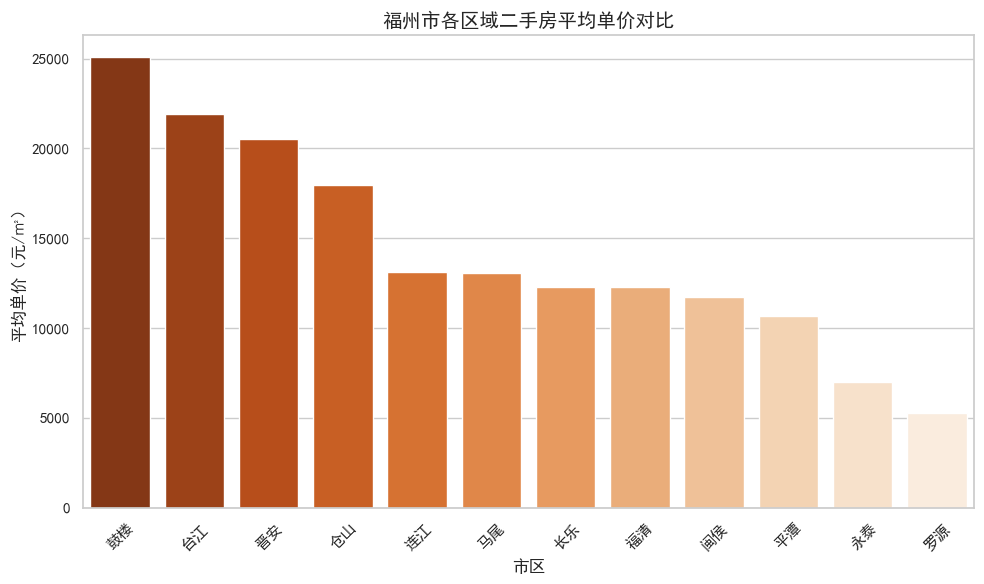

In [25]:
# 图表2：各市区平均单价对比
plt.figure(figsize=(10, 6))
sns.barplot(data=data, x='district', y='unit_price_num', 
            order=data.groupby('district')['unit_price_num'].mean().sort_values(ascending=False).index,
            palette='Oranges_r', errorbar=None)
plt.title('福州市各区域二手房平均单价对比', fontsize=14)
plt.xlabel('市区', fontsize=12)
plt.ylabel('平均单价（元/㎡）', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

图表解读：
该条形图清晰呈现了福州各板块的价格梯队。鼓楼区、台江区作为传统核心城区，教育、商业配套成熟，平均单价显著高于其他区域，处于第一价格梯队；仓山、晋安等城区单价处于中游水平；远郊板块单价最低，形成了由核心城区向外围递减的价格梯度，与城市资源分布高度匹配。

### 图表 3：户型占比饼图

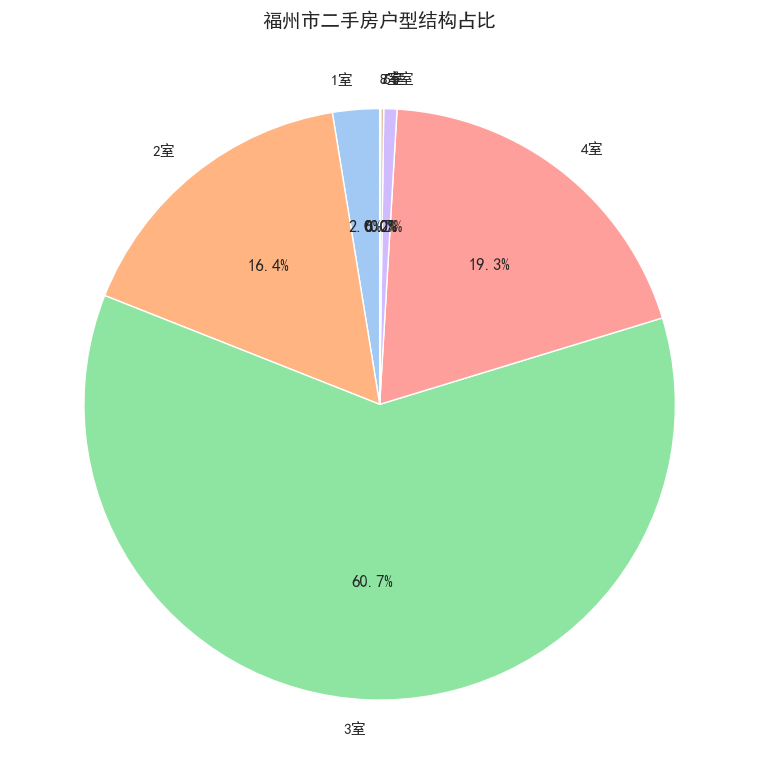

In [26]:
# 图表3：户型占比饼图
room_counts = data['room_num'].value_counts().sort_index()
plt.figure(figsize=(8, 8))
plt.pie(room_counts.values, 
        labels=[f'{i}室' for i in room_counts.index], 
        autopct='%.1f%%', 
        colors=sns.color_palette('pastel'), 
        startangle=90)
plt.title('福州市二手房户型结构占比', fontsize=14)
plt.tight_layout()
plt.show()

图表解读：
该饼图展示了市场房源的户型结构分布。3 室户型占比最高，占据市场主体份额，是福州二手房市场的绝对主流户型，对应刚需及首改群体的核心需求；2 室户型占比次之，满足刚需入门需求；4 室及以上大户型占比相对较低，对应改善型需求。整体户型结构呈现中间大、两头小的特征，与城市主流购房需求高度契合。

### 图表 4：面积与总价散点图

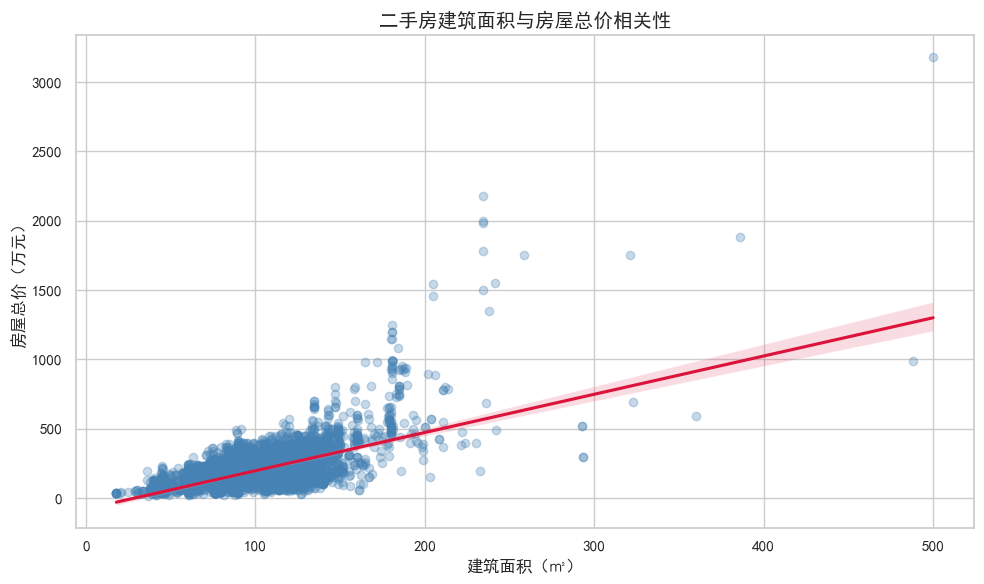

In [27]:
# 图表4：面积与总价散点图
plt.figure(figsize=(10, 6))
sns.regplot(data=data, x='area_num', y='total_price_num', 
            scatter_kws={'alpha':0.3, 'color':'steelblue'}, 
            line_kws={'color':'crimson'})
plt.title('二手房建筑面积与房屋总价相关性', fontsize=14)
plt.xlabel('建筑面积（㎡）', fontsize=12)
plt.ylabel('房屋总价（万元）', fontsize=12)
plt.tight_layout()
plt.show()

图表解读：
该散点图叠加趋势线展示了建筑面积与房屋总价的关联关系。整体来看，建筑面积与房屋总价呈现显著的正相关关系，面积越大总价越高，符合房地产市场的基本规律。同时散点存在一定离散度，说明除面积外，地段、楼层、朝向、房龄等因素也会对房屋总价产生影响，相同面积的房源会因其他属性差异出现价格分化。

---

## 8. 主要结论

本次基于福州11830套有效二手房挂牌数据，从数据质量校验、多维度描述统计、可视化分析等环节开展全流程研究，核心结论与对应数据支撑如下。

### 8.1 核心分析发现
1. **区域市场分化显著，供给规模与价格梯度呈反向分布**
    - 供给端：晋安区、仓山区是二手房市场主力供给板块，房源数量位居全市前两位，核心老城区与远郊区域供给量相对偏低，该结论由图表1「各区域房源数量分布」与市区分组统计结果共同支撑。
    - 价格端：市场形成清晰的三级价格梯队，鼓楼、台江核心城区平均单价最高，仓山、晋安城区处于中游水平，远郊板块单价最低，价格水平与城市教育、商业等资源配套的分布高度匹配，该结论由图表2「各区域平均单价对比」与市区分组聚合统计结果支撑。

2. **刚需与首改需求主导市场，3室户型为绝对主流供给**
    - 户型结构上，3室房源占比最高，是市场供给的绝对主力；2室刚需户型次之；4室及以上大户型占比偏低。整体户型结构呈现“中间大、两头小”的纺锤形分布，对应图表3「户型结构占比饼图」与室数分组统计结果。
    - 面积维度上，全市套均建筑面积约89㎡，半数房源面积集中在75-110㎡区间，与主流户型结构高度匹配，反映出刚需、首改是福州二手房市场的核心购房需求。

3. **面积是房价核心驱动因素，楼层、朝向存在稳定价格溢价**
    - 建筑面积与房屋总价呈现显著正相关关系，是影响房屋总价的最核心变量，该结论由图表4「面积-总价散点趋势图」与相关性统计结果支撑。
    - 房屋物理属性对单价存在稳定影响：高层房源整体单价高于中低层，南北通透朝向房源单价显著高于其他朝向，高层+南北向的组合为市场溢价最高的配置，该结论由6.4节楼层与朝向透视表交叉分析结果支撑。

4. **市场房源整体房龄偏新，高层住宅为绝对主流建筑形态**
    - 房龄维度，全市房源平均建造年份约2018年，以次新房为主，老旧住宅占比偏低，反映福州二手房市场的存量房源整体较新。
    - 建筑形态上，楼栋平均总层数约25层，高层住宅占据市场绝大多数，符合福州城区土地资源紧张、以高层住宅开发为主的市场特征，该结论由6.1节整体数值特征统计结果支撑。

### 8.2 数据局限与说明
1. **价格属性局限**：本次分析使用的价格为房源挂牌价格，并非最终成交价格，实际交易中通常存在议价空间。因此价格相关结论仅反映市场挂牌预期，不能完全等同于真实成交价格水平。
2. **样本覆盖局限**：数据仅覆盖福州市域范围的二手房挂牌房源，所有结论仅适用于福州本地市场，不能直接推广至其他城市或其他能级的房地产市场。
3. **字段提取误差**：楼层、户型、建造年份等衍生字段由原始文本规则提取得到，极个别特殊格式的房源可能存在提取偏差。该偏差对整体统计结果影响极小，但细分到极小样本分析时需谨慎解读。
4. **异常值影响**：数据中存在少量大户型、高总价的极端异常房源，均为真实市场房源，本次整体分析予以保留。若后续针对普通住宅开展细分研究，需先过滤极端值，避免均值出现偏移。